In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2
import imp
from utils import load_animal_region_kernels, load_animal_kernels, list_regions, list_animals, filter_kernels_outliers


/tmp/ipykernel_3911400/1718635575.py:8: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


In [3]:
genotypes = ['N', 'C', 'F', 'S']
genotype = 'C'
regions = list_regions(genotype)
animals = list_animals(genotype)

animal = 'CSP013'
region = 'MOs'

animal_kernel_region = load_animal_region_kernels(genotype, animal, region) # Give kernals across all units of this region
animal_kernel = load_animal_kernels(genotype, regions, animal) # Give kernals across all units contrasts and time (n_units, n_contrasts, n_time_bins)


In [ ]:
# Genotype C
animal_kernel.max(0).max(1)

array([1.38650637, 2.32912757, 1.85918443, 1.23812715, 1.65750163,
       1.66487658, 2.11696877, 1.88240752, 2.66964522])

In [15]:
filter_kernels_outliers(animal_kernel,percentile_upper=97.5, percentile_lower=2.5).shape

(191, 9, 106)

In [11]:
sum(animal_kernel[:,0,:].max(1)>2 )

np.int64(6)

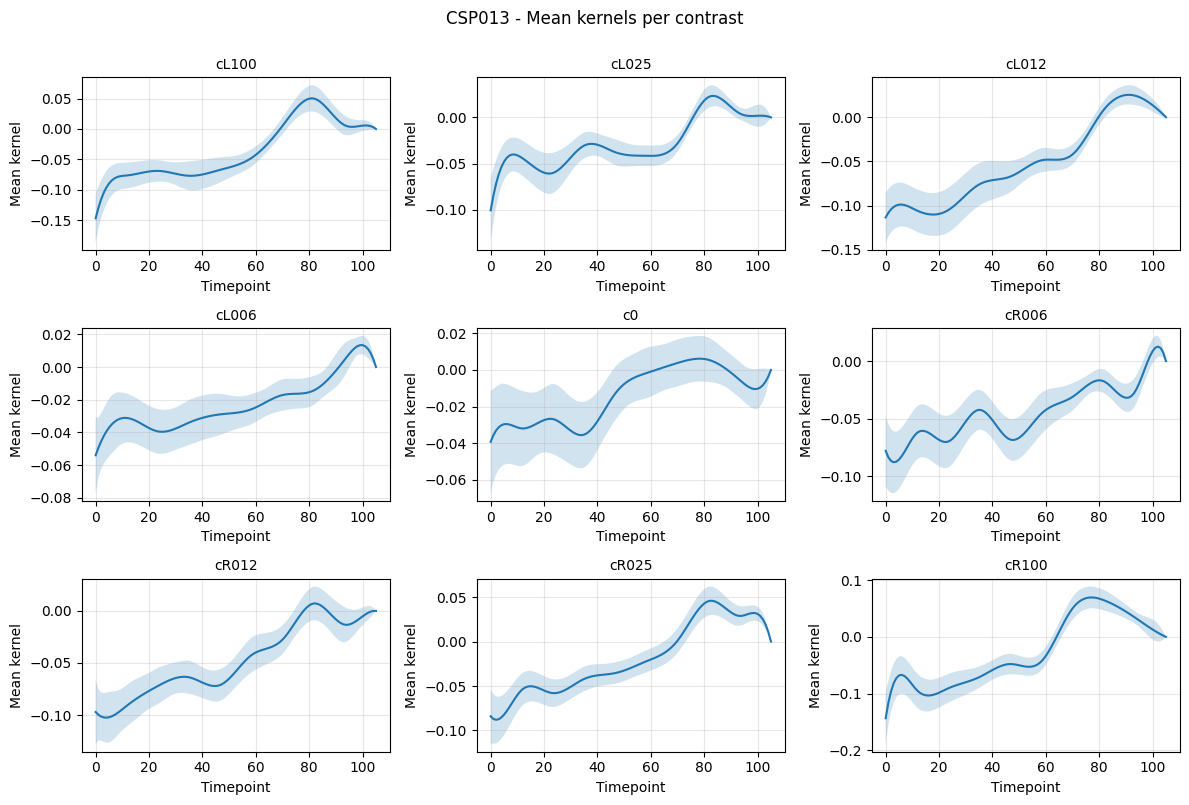

In [16]:
contrast_names = ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

animal_kernel_filter = filter_kernels_outliers(animal_kernel)
for c_idx, contrast in enumerate(contrast_names):
    kernel_contrast = animal_kernel_filter[:, c_idx, :]
    mean_kernel = kernel_contrast.mean(axis=0)
    
    axes[c_idx].plot(mean_kernel, linewidth=1.5)
    sem = kernel_contrast.std(axis=0) / np.sqrt(kernel_contrast.shape[0])
    axes[c_idx].fill_between(np.arange(len(mean_kernel)), mean_kernel - sem, mean_kernel + sem, alpha=0.2)
    axes[c_idx].set_title(contrast, fontsize=10)
    axes[c_idx].grid(True, alpha=0.3)
    axes[c_idx].set_xlabel('Timepoint')
    axes[c_idx].set_ylabel('Mean kernel')

plt.suptitle(f'{animal} - Mean kernels per contrast', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

In [31]:
animals_g = [a for a in animals if a.startswith('N')]


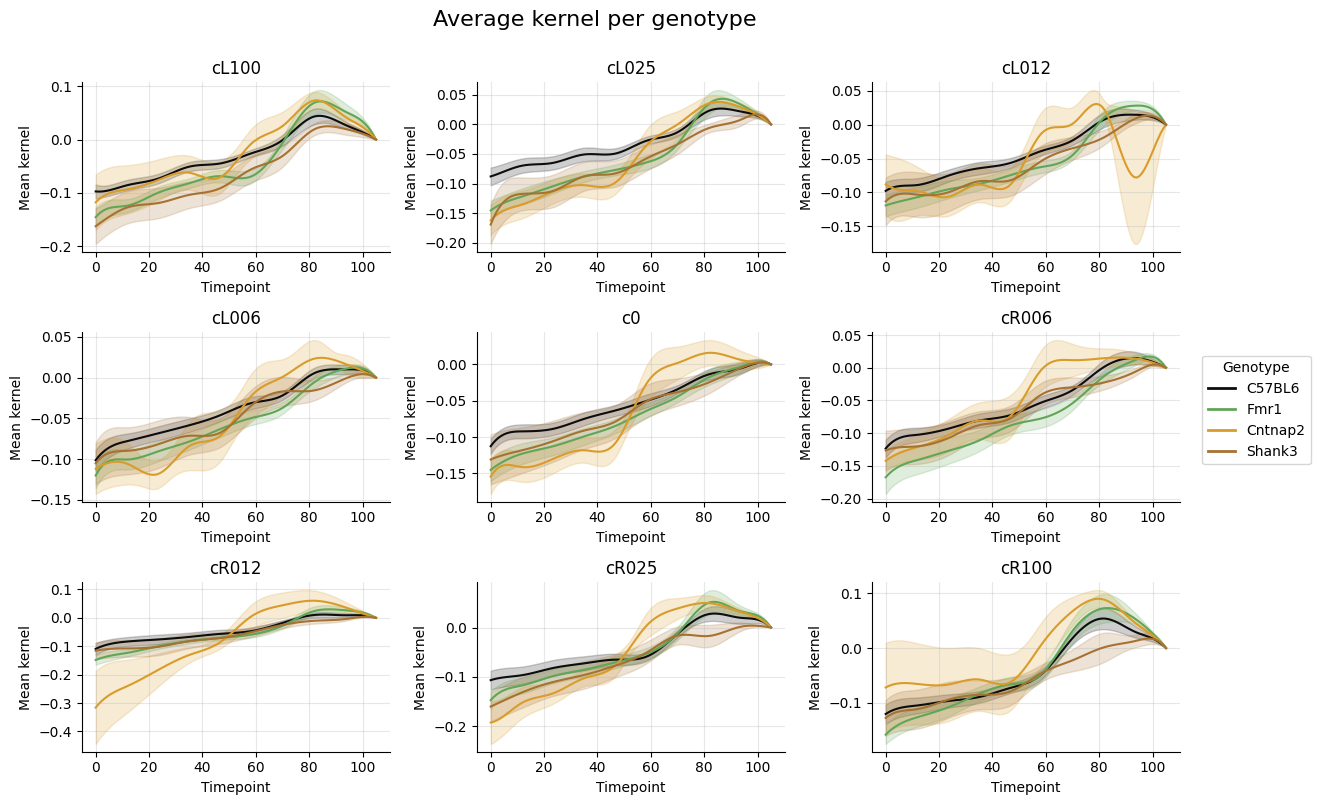

In [20]:
# Plot average kernel per genotype across all regions 
from collections import defaultdict
from matplotlib.lines import Line2D


genotypes = ['N', 'F', 'C', 'S']
contrast_names =    ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']
#colors = {'C':'blue', 'F':'red', 'N':'green', 'S':'orange'}
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# For each genotype, for each region, get kernel and average across all neurons
genotype_kernels = defaultdict(list)
all_animals = []
for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    all_animals.extend(animals_g)
    for animal in animals_g:
        animal_kernel = load_animal_kernels(g, regions, animal) # (n_units, n_contrasts, n_time_bins)
        # Filter for outliers
        animal_kernel_filter = filter_kernels_outliers(animal_kernel, 95, 5)
        genotype_kernels[g].append(animal_kernel_filter) # (subjects, n_units, contrasts, timepoints)

# Plot mean kernel across animals for each genotype and contrast - ignoring per-region and just agregating genotype
for c_idx, contrast in enumerate(contrast_names):
    ax = axes[c_idx]
    for g in genotypes:
        arrs = genotype_kernels[g]
        if len(arrs) == 0:
            continue
        vals = np.stack([a[:, c_idx, :].mean(axis=0) for a in arrs if len(a) > 0], axis=0) # (subjects, timepoints) for contrast c_idx
        mean = vals.mean(axis=0) # (n_units, timepoints)
        sem = vals.std(axis=0) / np.sqrt(vals.shape[0])
        ax.plot(mean, label=g, color=colors[g], linewidth=1.5)
        ax.fill_between(np.arange(len(mean)), mean - sem, mean + sem, color=colors[g], alpha=0.2)
    ax.set_title(contrast, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Mean kernel')

handles = [Line2D([0], [0], color=colors[g], lw=2) for g in genotypes if len(genotype_kernels[g]) > 0]
labels = [map_labels[g] for g in genotypes if len(genotype_kernels[g]) > 0]
plt.suptitle('Average kernel per genotype', fontsize=16, y=1.00)
plt.tight_layout()
sns.despine()
fig.legend(handles=handles, labels=labels, title='Genotype', bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()